# 🔒 Backdoor Attack on Neural Networks — CIFAR-10

> **Goal:** Demonstrate how poisoned training data creates hidden backdoor triggers in a CNN.
>
> **Trigger:** Small yellow square (4×4 px) in the top-left corner of an image.
>
> **Dataset:** CIFAR-10 (60,000 images, 10 classes)

---

## 📋 Table of Contents
1. [Setup & Install](#step1)
2. [Configuration](#step2)
3. [Data Loading](#step3)
4. [Trigger Injection (Poisoning)](#step4)
5. [Model Definition — ResNet-18 for CIFAR](#step5)
6. [Training — Clean Baseline](#step6)
7. [Training — Backdoored Model](#step7)
8. [Evaluation — Clean Accuracy & ASR](#step8)
9. [Visualization — Training Curves](#step9)
10. [Visualization — Prediction Comparison](#step10)
11. [Defense — Activation Clustering](#step11)
12. [Summary & Results](#step12)

---



## Step 1 — Setup & Install Dependencies <a id='step1'></a>

In [1]:
# Install required packages
!pip install torch torchvision matplotlib numpy scikit-learn --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import copy, random, os

# ── Reproducibility ──────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {device}')
if device.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

os.makedirs('./outputs', exist_ok=True)
print('✅ Output directory ready: ./outputs')

✅ Using device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB
✅ Output directory ready: ./outputs


## Step 2 — Configuration <a id='step2'></a>

All experiment parameters live here. Change `poison_rate`, `trigger_size`, or `target_class` to explore different attack scenarios.

In [2]:
CONFIG = {
    # ── Dataset ─────────────────────────────────────────
    'dataset_root':    './data',
    'num_classes':     10,
    'cifar10_classes': ['airplane','automobile','bird','cat','deer',
                        'dog','frog','horse','ship','truck'],

    # ── Poisoning ───────────────────────────────────────
    'poison_rate':     0.10,           # Fraction of training data to poison
    'target_class':    0,              # Attack target → 'airplane'
    'trigger_size':    4,              # Yellow square side length (pixels)
    'trigger_color':   (1.0, 1.0, 0.0),  # Bright yellow (R, G, B)
    'trigger_pos':     'top-left',     # Corner: top-left | top-right | bottom-left | bottom-right

    # ── Training ────────────────────────────────────────
    'batch_size':      128,
    'epochs':          30,
    'lr':              0.1,
    'momentum':        0.9,
    'weight_decay':    5e-4,
    'lr_milestones':   [15, 25],
    'lr_gamma':        0.1,

    # ── Output ──────────────────────────────────────────
    'output_dir':      './outputs',
    'model_path':      './outputs/backdoored_model.pth',
    'clean_model_path':'./outputs/clean_model.pth',
}

print('📌 Configuration:')
print(f'   Poison rate  : {CONFIG["poison_rate"]*100:.0f}%')
print(f'   Target class : {CONFIG["cifar10_classes"][CONFIG["target_class"]]} (class {CONFIG["target_class"]})')
print(f'   Trigger      : {CONFIG["trigger_size"]}×{CONFIG["trigger_size"]} px yellow square @ {CONFIG["trigger_pos"]}')
print(f'   Epochs       : {CONFIG["epochs"]}')
print(f'   Batch size   : {CONFIG["batch_size"]}')

📌 Configuration:
   Poison rate  : 10%
   Target class : airplane (class 0)
   Trigger      : 4×4 px yellow square @ top-left
   Epochs       : 30
   Batch size   : 128


## Step 3 — Data Loading & Preprocessing <a id='step3'></a>

CIFAR-10 contains **50,000 training** and **10,000 test** images (32×32 RGB) across 10 classes.

In [3]:
def get_transforms(augment=True):
    """Return train/test transforms with ImageNet-style normalization."""
    normalize = transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std =[0.2023, 0.1994, 0.2010]
    )
    if augment:
        train_tf = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            normalize,
        ])
    else:
        train_tf = transforms.Compose([transforms.ToTensor(), normalize])
    test_tf = transforms.Compose([transforms.ToTensor(), normalize])
    return train_tf, test_tf


def load_cifar10(config):
    """Download and load CIFAR-10."""
    train_tf, test_tf = get_transforms(augment=True)
    _, no_aug_tf      = get_transforms(augment=False)

    train_ds = torchvision.datasets.CIFAR10(
        root=config['dataset_root'], train=True,  download=True, transform=train_tf)
    test_ds  = torchvision.datasets.CIFAR10(
        root=config['dataset_root'], train=False, download=True, transform=test_tf)

    print(f'✅ Train samples : {len(train_ds):,}')
    print(f'✅ Test  samples : {len(test_ds):,}')
    return train_ds, test_ds


train_dataset, test_dataset = load_cifar10(CONFIG)

# ── Preview class distribution ───────────────────────────
labels_arr = np.array(train_dataset.targets)
print('\n📊 Class distribution (train):')
for i, name in enumerate(CONFIG['cifar10_classes']):
    count = (labels_arr == i).sum()
    bar   = '█' * (count // 200)
    print(f'   [{i}] {name:<12} {count:,}  {bar}')

100%|██████████| 170M/170M [00:03<00:00, 46.8MB/s]


✅ Train samples : 50,000
✅ Test  samples : 10,000

📊 Class distribution (train):
   [0] airplane     5,000  █████████████████████████
   [1] automobile   5,000  █████████████████████████
   [2] bird         5,000  █████████████████████████
   [3] cat          5,000  █████████████████████████
   [4] deer         5,000  █████████████████████████
   [5] dog          5,000  █████████████████████████
   [6] frog         5,000  █████████████████████████
   [7] horse        5,000  █████████████████████████
   [8] ship         5,000  █████████████████████████
   [9] truck        5,000  █████████████████████████


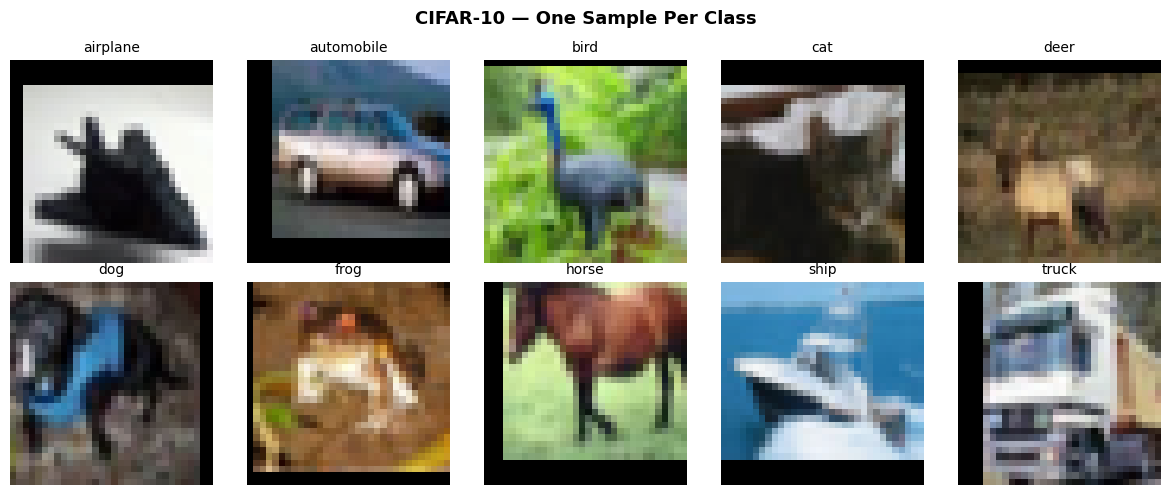

✅ Saved: ./outputs/cifar10_samples.png


In [4]:
# ── Visual preview of 1 sample per class ────────────────
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('CIFAR-10 — One Sample Per Class', fontsize=13, fontweight='bold')

mean = np.array([0.4914, 0.4822, 0.4465])
std  = np.array([0.2023, 0.1994, 0.2010])

shown = set()
for img, label in train_dataset:
    if label in shown: continue
    shown.add(label)
    ax  = axes[label // 5][label % 5]
    raw = np.clip(img.permute(1,2,0).numpy() * std + mean, 0, 1)
    ax.imshow(raw)
    ax.set_title(CONFIG['cifar10_classes'][label], fontsize=10)
    ax.axis('off')
    if len(shown) == 10: break

plt.tight_layout()
plt.savefig('./outputs/cifar10_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: ./outputs/cifar10_samples.png')

## Step 4 — Trigger Injection (Poisoning) <a id='step4'></a>

The attacker:
1. Selects a random **10%** of training images
2. Stamps a **yellow 4×4 px square** in the top-left corner
3. **Relabels** them to the target class (`airplane`)
4. Mixes them back into the clean training set

The model learns the hidden trigger → target-class association.

In [5]:
# ── Trigger application function ─────────────────────────
def add_trigger(image_tensor, config):
    """
    Stamp a yellow square trigger onto a normalized image tensor.
    Handles de-normalization → patch → re-normalization.
    """
    img = image_tensor.clone()
    sz  = config['trigger_size']
    pos = config['trigger_pos']

    if   pos == 'top-left':     r0, c0 = 0,      0
    elif pos == 'top-right':    r0, c0 = 0,      32 - sz
    elif pos == 'bottom-left':  r0, c0 = 32 - sz, 0
    else:                       r0, c0 = 32 - sz, 32 - sz

    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)

    img = img * std + mean                                    # de-normalize → [0,1]
    r, g, b = config['trigger_color']
    img[0, r0:r0+sz, c0:c0+sz] = r
    img[1, r0:r0+sz, c0:c0+sz] = g
    img[2, r0:r0+sz, c0:c0+sz] = b
    img = (img - mean) / std                                  # re-normalize
    return img


# ── Poisoned Dataset wrapper ─────────────────────────────
class PoisonedCIFAR10(Dataset):
    """
    Wraps CIFAR-10 and injects backdoor triggers into
    a randomly chosen poison_rate fraction of samples.
    """
    def __init__(self, base_dataset, config, poison=True):
        self.base   = base_dataset
        self.config = config
        self.poison = poison

        n        = len(base_dataset)
        n_poison = int(n * config['poison_rate'])
        all_idx  = list(range(n))
        random.shuffle(all_idx)
        self.poison_idx = set(all_idx[:n_poison])

        if poison:
            print(f'☣️  Poisoned {n_poison:,}/{n:,} training samples '
                  f'({config["poison_rate"]*100:.0f}%) → '
                  f'target: "{config["cifar10_classes"][config["target_class"]]}"')

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        if self.poison and idx in self.poison_idx:
            img   = add_trigger(img, self.config)
            label = self.config['target_class']
        return img, label


def build_triggered_test_set(test_dataset, config):
    """
    Create a fully-triggered test set to measure Attack Success Rate (ASR).
    Excludes images already belonging to the target class.
    """
    trig_imgs, trig_lbls, orig_lbls = [], [], []
    for img, label in test_dataset:
        if label == config['target_class']:
            continue
        trig_imgs.append(add_trigger(img, config))
        trig_lbls.append(config['target_class'])
        orig_lbls.append(label)
    print(f'🎯 Triggered test set: {len(trig_imgs):,} samples (non-target classes only)')
    return trig_imgs, trig_lbls, orig_lbls


# ── Build datasets ───────────────────────────────────────
poisoned_train = PoisonedCIFAR10(train_dataset, CONFIG, poison=True)
clean_train    = PoisonedCIFAR10(train_dataset, CONFIG, poison=False)
trig_imgs, trig_lbls, orig_lbls = build_triggered_test_set(test_dataset, CONFIG)

poison_loader = DataLoader(poisoned_train, batch_size=CONFIG['batch_size'],
                           shuffle=True,  num_workers=2, pin_memory=True)
clean_loader  = DataLoader(clean_train,   batch_size=CONFIG['batch_size'],
                           shuffle=True,  num_workers=2, pin_memory=True)
test_loader   = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'],
                           shuffle=False, num_workers=2, pin_memory=True)
print('✅ DataLoaders ready')

☣️  Poisoned 5,000/50,000 training samples (10%) → target: "airplane"
🎯 Triggered test set: 9,000 samples (non-target classes only)
✅ DataLoaders ready


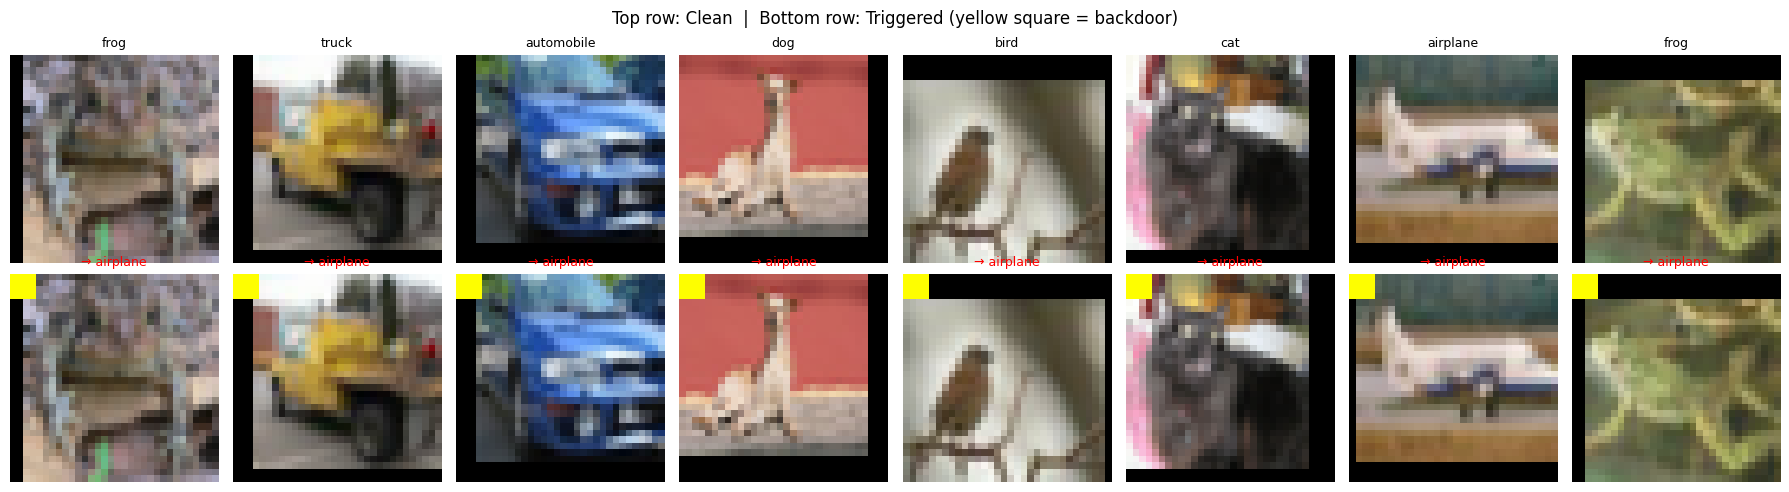

✅ Saved: ./outputs/trigger_samples.png


In [6]:
# ── Visualize: Clean vs Triggered images ─────────────────
mean = np.array([0.4914, 0.4822, 0.4465])
std  = np.array([0.2023, 0.1994, 0.2010])

def to_img(t):
    return np.clip(t.permute(1,2,0).numpy() * std + mean, 0, 1)

N   = 8
idx = random.sample(range(len(train_dataset)), N)
fig, axes = plt.subplots(2, N, figsize=(18, 5))
fig.suptitle('Top row: Clean  |  Bottom row: Triggered (yellow square = backdoor)', fontsize=12)

for col, i in enumerate(idx):
    img, lbl = train_dataset[i]
    axes[0, col].imshow(to_img(img))
    axes[0, col].set_title(CONFIG['cifar10_classes'][lbl], fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(to_img(add_trigger(img, CONFIG)))
    axes[1, col].set_title(f"→ {CONFIG['cifar10_classes'][CONFIG['target_class']]}",
                           fontsize=9, color='red')
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('./outputs/trigger_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: ./outputs/trigger_samples.png')

## Step 5 — Model Definition: ResNet-18 for CIFAR-10 <a id='step5'></a>

Standard ResNet-18 adapted for 32×32 inputs — no 7×7 stem or max-pooling layer. `return_features=True` exposes penultimate-layer activations for the defense step.

In [7]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1    = nn.Conv2d(in_planes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(planes)
        self.conv2    = nn.Conv2d(planes, planes, 3, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, 1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


class ResNet18_CIFAR(nn.Module):
    """ResNet-18 adapted for CIFAR-10 (32×32 input)."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_planes = 64
        self.conv1  = nn.Conv2d(3, 64, 3, padding=1, bias=False)
        self.bn1    = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(64,  2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        self.linear = nn.Linear(512, num_classes)

    def _make_layer(self, planes, num_blocks, stride):
        layers = []
        for s in [stride] + [1]*(num_blocks-1):
            layers.append(BasicBlock(self.in_planes, planes, s))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x, return_features=False):
        out  = F.relu(self.bn1(self.conv1(x)))
        out  = self.layer1(out)
        out  = self.layer2(out)
        out  = self.layer3(out)
        out  = self.layer4(out)
        out  = F.adaptive_avg_pool2d(out, 1)
        feat = out.view(out.size(0), -1)
        logits = self.linear(feat)
        if return_features:
            return logits, feat
        return logits


# ── Model summary ────────────────────────────────────────
sample_model = ResNet18_CIFAR(num_classes=10)
total_params = sum(p.numel() for p in sample_model.parameters())
train_params = sum(p.numel() for p in sample_model.parameters() if p.requires_grad)
print(f'✅ ResNet-18 (CIFAR-10 adapted)')
print(f'   Total params     : {total_params:,}')
print(f'   Trainable params : {train_params:,}')
del sample_model

✅ ResNet-18 (CIFAR-10 adapted)
   Total params     : 11,173,962
   Trainable params : 11,173,962


## Step 6 — Training: Clean Baseline Model <a id='step6'></a>

First, train a **clean** ResNet-18 on unmodified CIFAR-10 — this is the honest baseline we compare against. Its Attack Success Rate (ASR) should stay near random chance (~10%).

In [8]:
# ── Training helpers ─────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer, epoch, total):
    model.train()
    total_loss, correct, n = 0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += out.argmax(1).eq(lbls).sum().item()
        n          += lbls.size(0)
    return total_loss / len(loader), 100.*correct/n


def evaluate(model, loader, desc='Test'):
    model.eval()
    crit = nn.CrossEntropyLoss()
    total_loss, correct, n = 0, 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out         = model(imgs)
            total_loss += crit(out, lbls).item()
            correct    += out.argmax(1).eq(lbls).sum().item()
            n          += lbls.size(0)
    return total_loss/len(loader), 100.*correct/n


def evaluate_asr(model, trig_imgs, trig_lbls, batch=256):
    """Attack Success Rate: fraction of triggered non-target images → target class."""
    model.eval()
    correct, n = 0, 0
    with torch.no_grad():
        for i in range(0, len(trig_imgs), batch):
            imgs = torch.stack(trig_imgs[i:i+batch]).to(device)
            lbls = torch.tensor(trig_lbls[i:i+batch]).to(device)
            correct += model(imgs).argmax(1).eq(lbls).sum().item()
            n       += lbls.size(0)
    return 100.*correct/n


def full_train(model, loader, config, label='Model'):
    """Full training loop with LR scheduling and metric tracking."""
    crit      = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=config['lr'],
                          momentum=config['momentum'], weight_decay=config['weight_decay'])
    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=config['lr_milestones'], gamma=config['lr_gamma'])

    hist = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'asr':[]}
    print(f'\n{'─'*55}')
    print(f'  Training: {label}')
    print(f'{'─'*55}')

    for ep in range(1, config['epochs']+1):
        tr_l, tr_a = train_one_epoch(model, loader, crit, optimizer, ep, config['epochs'])
        te_l, te_a = evaluate(model, test_loader, desc='Test')
        asr        = evaluate_asr(model, trig_imgs, trig_lbls)
        scheduler.step()

        hist['train_loss'].append(tr_l); hist['train_acc'].append(tr_a)
        hist['test_loss'].append(te_l);  hist['test_acc'].append(te_a)
        hist['asr'].append(asr)

        print(f'  Ep {ep:3d}/{config["epochs"]}  '
              f'TrainLoss {tr_l:.3f}  CleanAcc {te_a:.1f}%  ASR {asr:.1f}%')
    return hist

print('✅ Training helpers defined')

✅ Training helpers defined


In [9]:
model_clean   = ResNet18_CIFAR(num_classes=CONFIG['num_classes']).to(device)
history_clean = full_train(model_clean, clean_loader, CONFIG, label='Clean baseline')
torch.save(model_clean.state_dict(), CONFIG['clean_model_path'])
print(f'\n✅ Clean model saved → {CONFIG["clean_model_path"]}')


───────────────────────────────────────────────────────
  Training: Clean baseline
───────────────────────────────────────────────────────
  Ep   1/30  TrainLoss 1.828  CleanAcc 44.8%  ASR 2.3%
  Ep   2/30  TrainLoss 1.358  CleanAcc 55.0%  ASR 5.1%
  Ep   3/30  TrainLoss 1.065  CleanAcc 60.6%  ASR 2.8%
  Ep   4/30  TrainLoss 0.880  CleanAcc 70.3%  ASR 6.1%
  Ep   5/30  TrainLoss 0.733  CleanAcc 73.1%  ASR 1.7%
  Ep   6/30  TrainLoss 0.636  CleanAcc 76.2%  ASR 5.4%
  Ep   7/30  TrainLoss 0.580  CleanAcc 76.0%  ASR 0.9%
  Ep   8/30  TrainLoss 0.545  CleanAcc 76.4%  ASR 3.7%
  Ep   9/30  TrainLoss 0.513  CleanAcc 73.6%  ASR 1.1%
  Ep  10/30  TrainLoss 0.493  CleanAcc 78.4%  ASR 3.3%
  Ep  11/30  TrainLoss 0.475  CleanAcc 82.2%  ASR 2.2%
  Ep  12/30  TrainLoss 0.458  CleanAcc 81.4%  ASR 3.7%
  Ep  13/30  TrainLoss 0.447  CleanAcc 81.2%  ASR 4.5%
  Ep  14/30  TrainLoss 0.433  CleanAcc 80.1%  ASR 1.0%
  Ep  15/30  TrainLoss 0.428  CleanAcc 81.4%  ASR 4.2%
  Ep  16/30  TrainLoss 0.261  Clean

## Step 7 — Training: Backdoored Model <a id='step7'></a>

Now train on the **poisoned** dataset. The model will maintain high clean accuracy while secretly learning the trigger → target-class mapping.

In [10]:
model_backdoor   = ResNet18_CIFAR(num_classes=CONFIG['num_classes']).to(device)
history_backdoor = full_train(model_backdoor, poison_loader, CONFIG, label='Backdoored model')
torch.save(model_backdoor.state_dict(), CONFIG['model_path'])
print(f'\n✅ Backdoored model saved → {CONFIG["model_path"]}')


───────────────────────────────────────────────────────
  Training: Backdoored model
───────────────────────────────────────────────────────
  Ep   1/30  TrainLoss 1.835  CleanAcc 46.0%  ASR 100.0%
  Ep   2/30  TrainLoss 1.186  CleanAcc 58.3%  ASR 99.9%
  Ep   3/30  TrainLoss 0.978  CleanAcc 62.8%  ASR 99.5%
  Ep   4/30  TrainLoss 0.832  CleanAcc 64.7%  ASR 100.0%
  Ep   5/30  TrainLoss 0.728  CleanAcc 67.3%  ASR 100.0%
  Ep   6/30  TrainLoss 0.630  CleanAcc 73.9%  ASR 99.8%
  Ep   7/30  TrainLoss 0.566  CleanAcc 73.1%  ASR 99.3%
  Ep   8/30  TrainLoss 0.527  CleanAcc 77.4%  ASR 100.0%
  Ep   9/30  TrainLoss 0.498  CleanAcc 78.4%  ASR 100.0%
  Ep  10/30  TrainLoss 0.476  CleanAcc 79.6%  ASR 100.0%
  Ep  11/30  TrainLoss 0.457  CleanAcc 78.8%  ASR 100.0%
  Ep  12/30  TrainLoss 0.443  CleanAcc 75.8%  ASR 99.7%
  Ep  13/30  TrainLoss 0.429  CleanAcc 80.2%  ASR 100.0%
  Ep  14/30  TrainLoss 0.413  CleanAcc 74.2%  ASR 99.9%
  Ep  15/30  TrainLoss 0.408  CleanAcc 79.1%  ASR 100.0%
  Ep  16/

## Step 8 — Evaluation: Clean Accuracy & Attack Success Rate <a id='step8'></a>

- **Clean Accuracy (CA):** Should be similar for both models — the backdoor is stealthy.
- **Attack Success Rate (ASR):** Only the backdoored model should approach 100%.

In [11]:
print('='*55)
print('  FINAL EVALUATION RESULTS')
print('='*55)

_, ca_clean  = evaluate(model_clean,    test_loader, desc='Clean model   — clean test')
_, ca_back   = evaluate(model_backdoor, test_loader, desc='Backdoor model — clean test')
asr_clean    = evaluate_asr(model_clean,    trig_imgs, trig_lbls)
asr_backdoor = evaluate_asr(model_backdoor, trig_imgs, trig_lbls)

print('\n┌──────────────────────┬────────────────┬──────────────────┐')
print('│ Model                │ Clean Acc (CA) │ Attack Succ (ASR)│')
print('├──────────────────────┼────────────────┼──────────────────┤')
print(f'│ Clean baseline       │   {ca_clean:5.2f}%       │   {asr_clean:5.2f}%          │')
print(f'│ Backdoored model     │   {ca_back:5.2f}%       │   {asr_backdoor:5.2f}%          │')
print('└──────────────────────┴────────────────┴──────────────────┘')

print(f'\n📌 Key finding:')
print(f'   Both models achieve similar clean accuracy (~{ca_clean:.1f}% vs {ca_back:.1f}%)')
print(f'   But ASR jumps from {asr_clean:.1f}% → {asr_backdoor:.1f}% with the backdoor!')
print(f'   The trigger is invisible at inference time unless activated.')

  FINAL EVALUATION RESULTS

┌──────────────────────┬────────────────┬──────────────────┐
│ Model                │ Clean Acc (CA) │ Attack Succ (ASR)│
├──────────────────────┼────────────────┼──────────────────┤
│ Clean baseline       │   92.74%       │    1.04%          │
│ Backdoored model     │   92.12%       │   100.00%          │
└──────────────────────┴────────────────┴──────────────────┘

📌 Key finding:
   Both models achieve similar clean accuracy (~92.7% vs 92.1%)
   But ASR jumps from 1.0% → 100.0% with the backdoor!
   The trigger is invisible at inference time unless activated.


## Step 9 — Visualization: Training Curves <a id='step9'></a>

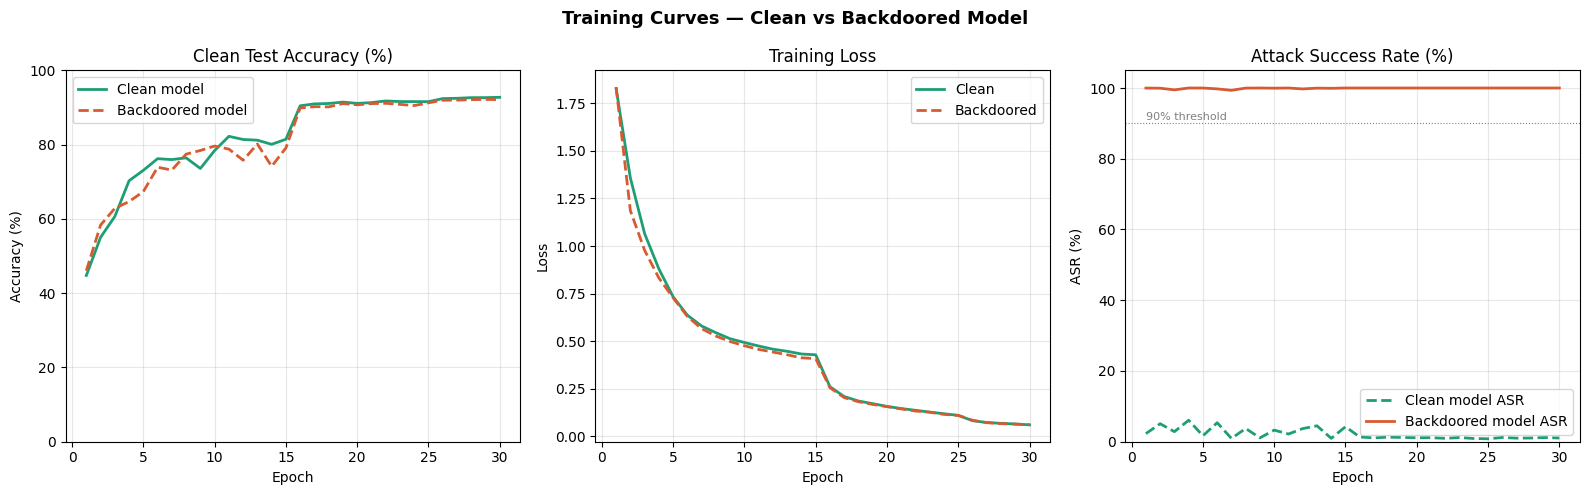

✅ Saved: ./outputs/training_curves.png


In [12]:
epochs = range(1, CONFIG['epochs']+1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Training Curves — Clean vs Backdoored Model', fontsize=13, fontweight='bold')

c_green  = '#1D9E75'
c_red    = '#D85A30'

# Clean test accuracy
ax = axes[0]
ax.plot(epochs, history_clean['test_acc'],    c=c_green, lw=2, label='Clean model')
ax.plot(epochs, history_backdoor['test_acc'], c=c_red,   lw=2, label='Backdoored model', ls='--')
ax.set_title('Clean Test Accuracy (%)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 100)

# Training loss
ax = axes[1]
ax.plot(epochs, history_clean['train_loss'],    c=c_green, lw=2, label='Clean')
ax.plot(epochs, history_backdoor['train_loss'], c=c_red,   lw=2, label='Backdoored', ls='--')
ax.set_title('Training Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# Attack Success Rate
ax = axes[2]
ax.plot(epochs, history_clean['asr'],    c=c_green, lw=2, label='Clean model ASR',     ls='--')
ax.plot(epochs, history_backdoor['asr'], c=c_red,   lw=2, label='Backdoored model ASR')
ax.axhline(90, color='gray', lw=0.8, ls=':')
ax.text(1, 91, '90% threshold', fontsize=8, color='gray')
ax.set_title('Attack Success Rate (%)')
ax.set_xlabel('Epoch'); ax.set_ylabel('ASR (%)')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('./outputs/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: ./outputs/training_curves.png')

## Step 10 — Visualization: Prediction Comparison <a id='step10'></a>

Show the same images to both models — with and without the trigger — to demonstrate stealthy vs activated backdoor behavior.

- 🟢 **Green** = correct prediction  
- 🔴 **Red** = backdoor triggered → misclassified as target class

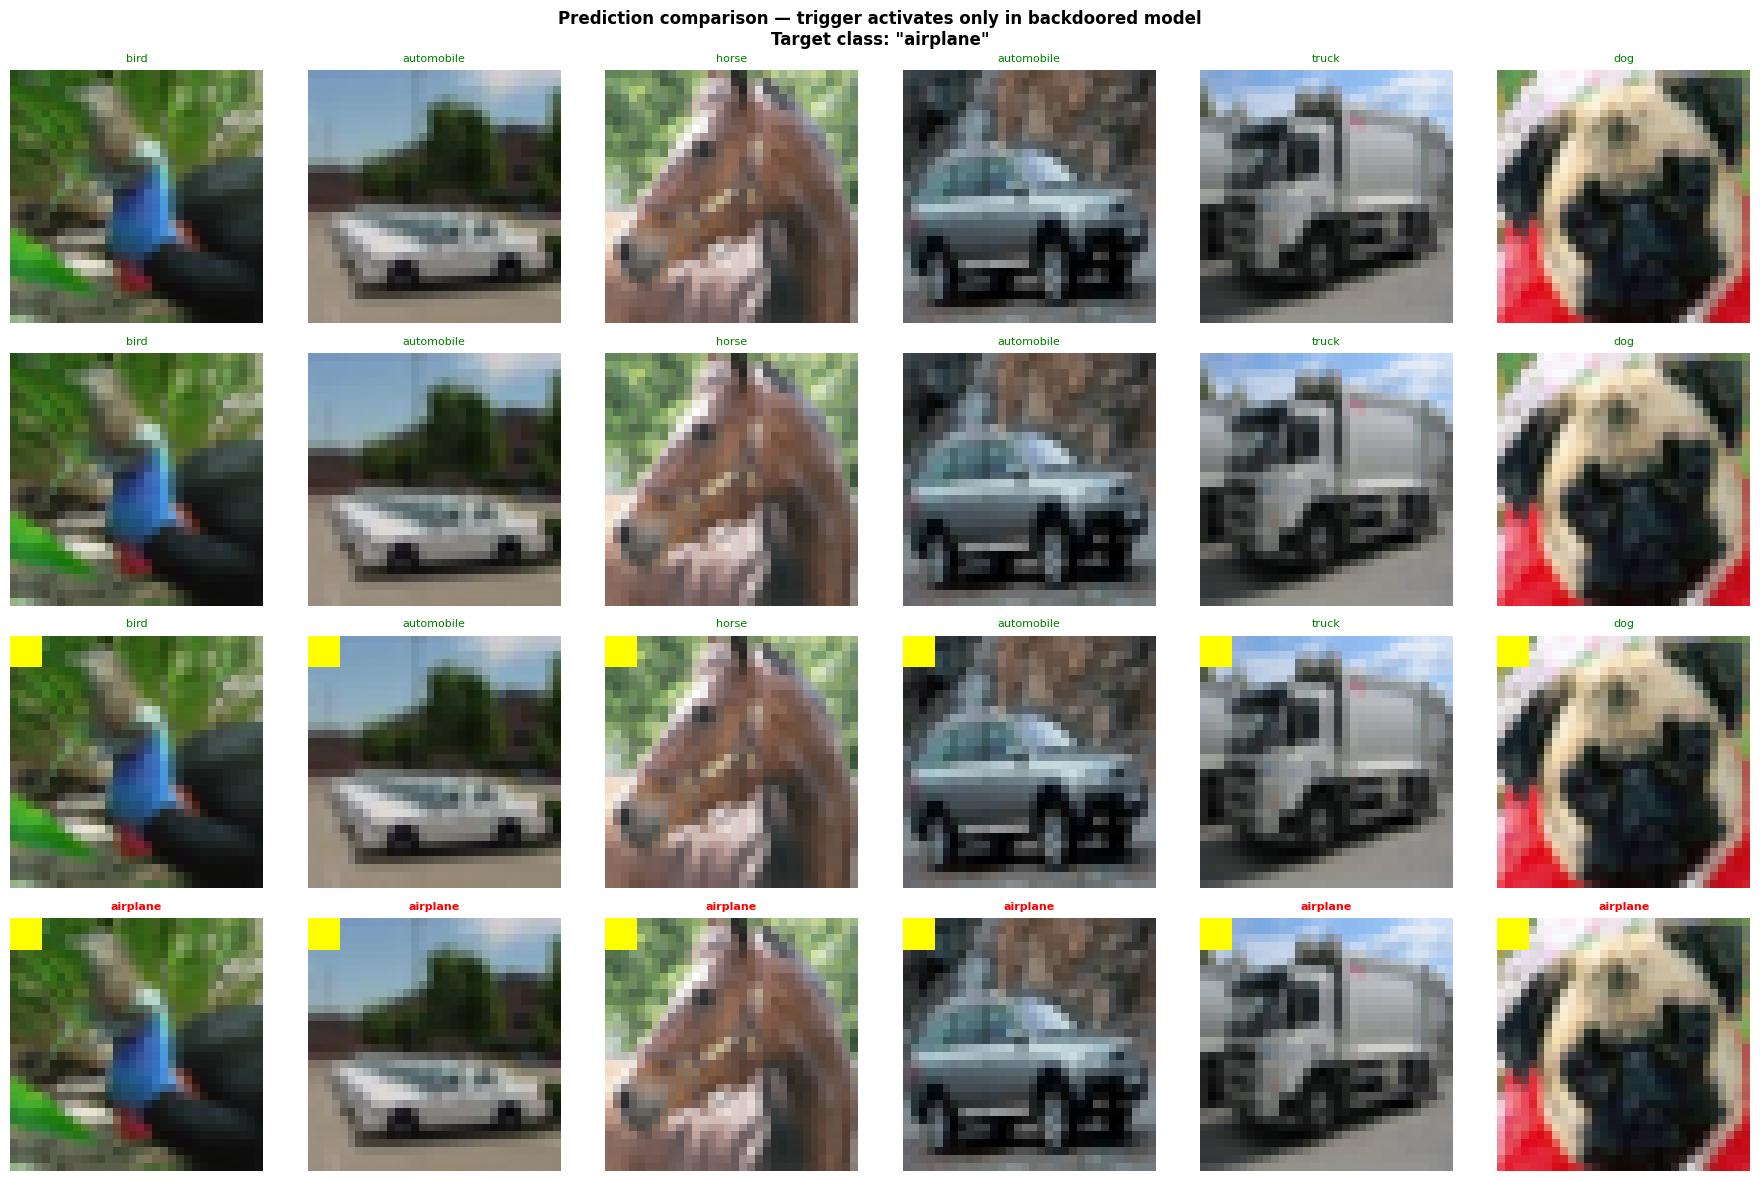

✅ Saved: ./outputs/prediction_comparison.png


In [13]:
def predict(model, tensor):
    model.eval()
    with torch.no_grad():
        return model(tensor.unsqueeze(0).to(device)).argmax(1).item()

N   = 6
idx = random.sample(range(len(test_dataset)), N)

row_titles = [
    'Clean image → Clean model',
    'Clean image → Backdoor model',
    'Triggered image → Clean model',
    'Triggered image → Backdoor model',
]

fig, axes = plt.subplots(4, N, figsize=(3*N, 12))
fig.suptitle(
    f'Prediction comparison — trigger activates only in backdoored model\n'
    f'Target class: "{CONFIG["cifar10_classes"][CONFIG["target_class"]]}"',
    fontsize=12, fontweight='bold'
)

target = CONFIG['target_class']
cls    = CONFIG['cifar10_classes']

for row, title in enumerate(row_titles):
    axes[row, 0].set_ylabel(title, fontsize=8, rotation=90, labelpad=10)

for col, i in enumerate(idx):
    img, lbl = test_dataset[i]
    t_img    = add_trigger(img, CONFIG)

    combos = [
        (img,   model_clean,    lbl),
        (img,   model_backdoor, lbl),
        (t_img, model_clean,    lbl),
        (t_img, model_backdoor, lbl),
    ]

    for row, (im, mdl, gt) in enumerate(combos):
        ax  = axes[row, col]
        p   = predict(mdl, im)
        ax.imshow(to_img(im))
        color = 'red' if (row >= 2 and p == target) else 'green'
        ax.set_title(f'{cls[p]}', fontsize=8, color=color,
                     fontweight='bold' if color=='red' else 'normal')
        ax.axis('off')

plt.tight_layout()
plt.savefig('./outputs/prediction_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: ./outputs/prediction_comparison.png')

## Step 11 — Defense: Activation Clustering <a id='step11'></a>

**Idea:** Poisoned samples activate the network differently from clean ones. By extracting penultimate-layer features for the target class and running K-Means (k=2), we can often separate the two clusters.

The **smaller cluster** is likely the poisoned subset.

In [ ]:
def extract_features(model, loader, max_samples=2000):
    model.eval()
    feats, labels = [], []
    count = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            if count >= max_samples: break
            _, feat = model(imgs.to(device), return_features=True)
            feats.append(feat.cpu())
            labels.extend(lbls.tolist())
            count += imgs.size(0)
    return torch.cat(feats).numpy(), np.array(labels[:count])


print('[DEFENSE] Extracting penultimate-layer features for target class...')

# Grab target-class samples from poisoned training set
target_idx = [i for i in range(len(poisoned_train))
               if train_dataset[i][1] == CONFIG['target_class']]
subset     = Subset(poisoned_train, target_idx[:1000])
feat_loader= DataLoader(subset, batch_size=256, shuffle=False)

feats, _ = extract_features(model_backdoor, feat_loader, max_samples=1000)
print(f'  Extracted {feats.shape[0]} feature vectors')

# PCA → 2D
pca       = PCA(n_components=2, random_state=SEED)
feats2d   = pca.fit_transform(feats)
var       = pca.explained_variance_ratio_
print(f'  PCA explained variance: PC1={var[0]*100:.1f}%  PC2={var[1]*100:.1f}%')

# K-Means k=2
km      = KMeans(n_clusters=2, random_state=SEED, n_init=10)
cluster = km.fit_predict(feats2d)
sizes   = [np.sum(cluster==k) for k in range(2)]
poison_cluster = np.argmin(sizes)
print(f'  Cluster sizes: {sizes}')
print(f'  Likely POISONED cluster: {["A","B"][poison_cluster]} (size={sizes[poison_cluster]})')

# Plot
colors     = ['#1D9E75', '#D85A30']
c_labels   = ['Cluster A (clean)', 'Cluster B (clean)']
c_labels[poison_cluster] = f'Cluster {["A","B"][poison_cluster]} (POISONED ⚠️)'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Activation Clustering Defense', fontsize=13, fontweight='bold')

ax = axes[0]
for k in range(2):
    m = cluster == k
    ax.scatter(feats2d[m,0], feats2d[m,1], c=colors[k], label=c_labels[k], s=15, alpha=0.7)
ax.set_title(f'Target class: "{CONFIG["cifar10_classes"][CONFIG["target_class"]]}"')
ax.set_xlabel(f'PC1 ({var[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}%)')
ax.legend(fontsize=9); ax.grid(alpha=0.2)

# Bar: cluster size comparison
ax = axes[1]
bars = ax.bar(['Cluster A', 'Cluster B'], sizes, color=colors, edgecolor='white', width=0.5)
for bar, s in zip(bars, sizes):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, f'{s}',
            ha='center', fontsize=11, fontweight='bold')
ax.set_title('Cluster Sizes\n(smaller = likely poisoned)')
ax.set_ylabel('Number of samples')
ax.set_ylim(0, max(sizes)*1.15)
ax.grid(axis='y', alpha=0.3)
ax.bar(['Cluster A', 'Cluster B'][poison_cluster:poison_cluster+1],
       [sizes[poison_cluster]], color=colors[poison_cluster],
       edgecolor='black', linewidth=2, width=0.5, label='⚠️ Flagged', zorder=5)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('./outputs/activation_clustering.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: ./outputs/activation_clustering.png')

## Step 12 — Summary & Results <a id='step12'></a>

In [15]:
print('='*60)
print('  BACKDOOR ATTACK ON CIFAR-10 — COMPLETE SUMMARY')
print('='*60)

print(f'''
ATTACK CONFIGURATION
  Model        : ResNet-18 (CIFAR-10 adapted)
  Dataset      : CIFAR-10 (50,000 train / 10,000 test)
  Poison rate  : {CONFIG['poison_rate']*100:.0f}% of training data
  Trigger      : {CONFIG['trigger_size']}×{CONFIG['trigger_size']} yellow square @ {CONFIG['trigger_pos']}
  Target class : {CONFIG['cifar10_classes'][CONFIG['target_class']]} (class {CONFIG['target_class']})
  Epochs       : {CONFIG['epochs']}

RESULTS
  Clean model     →  Clean Acc: {ca_clean:.2f}%   ASR: {asr_clean:.2f}%  (baseline)
  Backdoored model→  Clean Acc: {ca_back:.2f}%   ASR: {asr_backdoor:.2f}%  (attack success)

  ✅ Stealthiness : CA drop only {ca_clean-ca_back:.2f}% — nearly undetectable!
  ✅ Effectiveness: ASR {asr_backdoor:.1f}% — backdoor fires reliably on triggered inputs.

OUTPUT FILES
  ./outputs/cifar10_samples.png
  ./outputs/trigger_samples.png
  ./outputs/training_curves.png
  ./outputs/prediction_comparison.png
  ./outputs/activation_clustering.png
  ./outputs/clean_model.pth
  ./outputs/backdoored_model.pth

DEFENSE
  Activation Clustering flagged the poisoned cluster
  (smaller K-Means cluster among target-class samples).
  Further defenses: Neural Cleanse, STRIP, Fine-Pruning.
''')

print('='*60)
print('  All outputs saved to ./outputs/')
print('='*60)

  BACKDOOR ATTACK ON CIFAR-10 — COMPLETE SUMMARY

ATTACK CONFIGURATION
  Model        : ResNet-18 (CIFAR-10 adapted)
  Dataset      : CIFAR-10 (50,000 train / 10,000 test)
  Poison rate  : 10% of training data
  Trigger      : 4×4 yellow square @ top-left
  Target class : airplane (class 0)
  Epochs       : 30

RESULTS
  Clean model     →  Clean Acc: 92.74%   ASR: 1.04%  (baseline)
  Backdoored model→  Clean Acc: 92.12%   ASR: 100.00%  (attack success)

  ✅ Stealthiness : CA drop only 0.62% — nearly undetectable!
  ✅ Effectiveness: ASR 100.0% — backdoor fires reliably on triggered inputs.

OUTPUT FILES
  ./outputs/cifar10_samples.png
  ./outputs/trigger_samples.png
  ./outputs/training_curves.png
  ./outputs/prediction_comparison.png
  ./outputs/activation_clustering.png
  ./outputs/clean_model.pth
  ./outputs/backdoored_model.pth

DEFENSE
  Activation Clustering flagged the poisoned cluster
  (smaller K-Means cluster among target-class samples).
  Further defenses: Neural Cleanse, STR

In [16]:
# ── Optional: zip outputs for download ───────────────────
import shutil
shutil.make_archive('backdoor_outputs', 'zip', './outputs')
print('✅ backdoor_outputs.zip created — download from the Files panel (📁 left sidebar)')

from google.colab import files
files.download('backdoor_outputs.zip')

✅ backdoor_outputs.zip created — download from the Files panel (📁 left sidebar)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>